# Low correlation, $S_\mu$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import sys
from scipy.special import legendre
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sys.path.insert(1, '../../scripts')
import CMBanom

In [2]:
# Parameters
Nside      = 128
method     = "summation"
Nmus       = 41
mus        = np.linspace(-1, 1, Nmus)
mu_index   = 30; print(mus[mu_index])
save_stats = True

load_stats_from_cluster = True

if load_stats_from_cluster: Nsims = 100000
else:                       Nsims = 1000

0.5


In [3]:
print(mus)

[-1.   -0.95 -0.9  -0.85 -0.8  -0.75 -0.7  -0.65 -0.6  -0.55 -0.5  -0.45
 -0.4  -0.35 -0.3  -0.25 -0.2  -0.15 -0.1  -0.05  0.    0.05  0.1   0.15
  0.2   0.25  0.3   0.35  0.4   0.45  0.5   0.55  0.6   0.65  0.7   0.75
  0.8   0.85  0.9   0.95  1.  ]


In [4]:
# Directories
sims_dir = '../../data/sims/sims_1k/'
real_dir = "../../data/real/"
stats_dir = "../../data/stats/"

# Planck maps  
#names_Planck  = [ "v9_70GHz_nside_128", "v9_94GHz_nside_128", "v9_100GHz_nside_128", "v9_143GHz_nside_128", "commander_nside_128",        "nilc_nside_128",      "sevem_nside_128",   "smica_nside_128"]
#names_Planck  = [ "v9_70GHz_LCDMdebias",   "v9_94GHz_LCDMdebias", "v9_100GHz_LCDMdebias", "v9_143GHz_LCDMdebias", "commander_nside_128", "nilc_nside_128",      "sevem_nside_128",   "smica_nside_128", ]
names_Planck  = [  "v9_70GHz_POBSdebias",   "v9_94GHz_POBSdebias",  "v9_100GHz_POBSdebias",  "v9_143GHz_POBSdebias",   "commander_nside_128",   "nilc_nside_128",   "sevem_nside_128",   "smica_nside_128"]
labels_Planck = [ r"$70\, \mathrm{GHz}$",  r"$94\, \mathrm{GHz}$", r"$100\, \mathrm{GHz}$", r"$143\, \mathrm{GHz}$", r"$\mathrm{Commander}$", r"$\mathrm{NILC}$", r"$\mathrm{SEVEM}$", r"$\mathrm{SMICA}$"]

colors_Planck = [  "tab:red", "teal",  "navy",  "gold", "tab:red",    "teal",   "navy",   "gold"]
lss_Planck    = [        "-",    "-",     "-",     "-",      "--",      "--",     "--",     "--"]
color_qml     = "green"
label_qml     = r"$\mathrm{Public\ QML-}C_\ell$"
index_Hayley  = 2
index_Planck  = 6
Nmaps = len(names_Planck)

# Masks
names_mask  = [              "fullsky",                "stdmask",                  "commask"]
labels_mask = [r"$\mathrm{Full\ sky}$", r"$\mathrm{Std.\ mask}$", r"$\mathrm{Common\ mask}$"]
colors_mask = [             "tab:blue",                   "navy",                "firebrick"]
Nmasks = len(names_mask)

# Cls
fn_cl_theory = "../../data/real/COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt"
fn_cl_qml    = "../../data/real/COM_PowerSpect_CMB-TT-full_R3.01.txt"

In [5]:
# Font
plt.rc('font',**{'family':'Helvetica','size':20})
plt.rc('text', usetex=True)
font = {'family':'Helvetica',
        'color' : 'black',
        'size'  :  20}

In [6]:
# Same l-range for all Cls
lmax = 384
ll = np.arange(lmax)

In [7]:
# Load Planck Cl (begins with l=0) - *no* window fcts. correction, shape: (Nmasks, Nmaps, lmax)
cl_Planck = np.array([[np.loadtxt(real_dir+"cl_"+names_Planck[n]+"_"+names_mask[m]+".txt").T[1] for n in range(Nmaps)] for m in range(Nmasks)])

# Compute corr from Cls
theta, cos_theta = np.loadtxt(real_dir+"corr_"+names_Planck[4]+"_"+names_mask[0]+".txt").T[:2]
corr_Planck = np.array([[CMBanom.corr_from_cl(theta, cl_Planck[m][n], lmax=lmax) for n in range(Nmaps)] for m in range(Nmasks)])

/Users/lherold/Applications/anaconda3/lib/python3.7/site-packages/scipy/special/orthogonal.py:139: RuntimeWarning: invalid value encountered in multiply
  np.poly1d.__init__(self, poly.coeffs * float(kn))
/Users/lherold/Applications/anaconda3/lib/python3.7/site-packages/scipy/special/orthogonal.py:2131: RuntimeWarning: overflow encountered in double_scalars
  kn = _gam(2 * n + 1) / _gam(n + 1)**2 / 2.0**n
/Users/lherold/Applications/anaconda3/lib/python3.7/site-packages/scipy/special/orthogonal.py:2131: RuntimeWarning: invalid value encountered in double_scalars
  kn = _gam(2 * n + 1) / _gam(n + 1)**2 / 2.0**n


In [8]:
# Load theory Cl used to generate (begins with l=2)
dl_theory = np.append(np.zeros(2), np.loadtxt(fn_cl_theory, skiprows=1).T[1])[:lmax]
corr_theory = CMBanom.corr_from_cl(theta, dl_theory[2:]/(ll[2:]*(ll[2:]+1)/(2*np.pi)))

In [9]:
# Load QML Cl's (begins with l=2)
dl_qml = np.loadtxt(fn_cl_qml).T[1][:lmax-2]
cl_qml = np.append(np.zeros(2), dl_qml/ll[2:]/(1+ll[2:])*2*np.pi)

# Compute C(theta) from QML Cl's
corr_qml = CMBanom.corr_from_cl(theta, cl_qml, lmax=lmax)

In [10]:
# Get sim envelope
if load_stats_from_cluster:
    mean_corrs = np.array([np.loadtxt(stats_dir+"corr_mean_perc_"+names_mask[m]+".npy")[0] for m in range(Nmasks)])
    perc_68_lower = np.array([np.loadtxt(stats_dir+"corr_mean_perc_"+names_mask[m]+".npy")[1] for m in range(Nmasks)])
    perc_68_upper = np.array([np.loadtxt(stats_dir+"corr_mean_perc_"+names_mask[m]+".npy")[2] for m in range(Nmasks)])
    perc_95_lower = np.array([np.loadtxt(stats_dir+"corr_mean_perc_"+names_mask[m]+".npy")[3] for m in range(Nmasks)])
    perc_95_upper = np.array([np.loadtxt(stats_dir+"corr_mean_perc_"+names_mask[m]+".npy")[4] for m in range(Nmasks)])
else: 
    cls,corrs = np.zeros((Nmasks, Nsims, lmax)), np.zeros((Nmasks, Nsims, lmax))
    for m in range(Nmasks):
        corrs[m] = CMBanom.load_corrs(sims_dir, names_mask[m], Nsims)[2]
        cls[m]   = CMBanom.load_cls(sims_dir, names_mask[m], Nsims, cl_wf)
    mean_corrs = np.mean(corrs, axis=1)
    std_corrs = np.std(corrs, axis=1)
    perc_68_lower = np.percentile(corrs, (100-68.27)/2, axis=1)
    perc_68_upper = np.percentile(corrs, 68.27+(100-68.27)/2, axis=1)
    perc_95_lower = np.percentile(corrs, (100-95.45)/2, axis=1)
    perc_95_upper = np.percentile(corrs, 95.45+(100-95.45)/2, axis=1)

## Plot $C(\theta)$

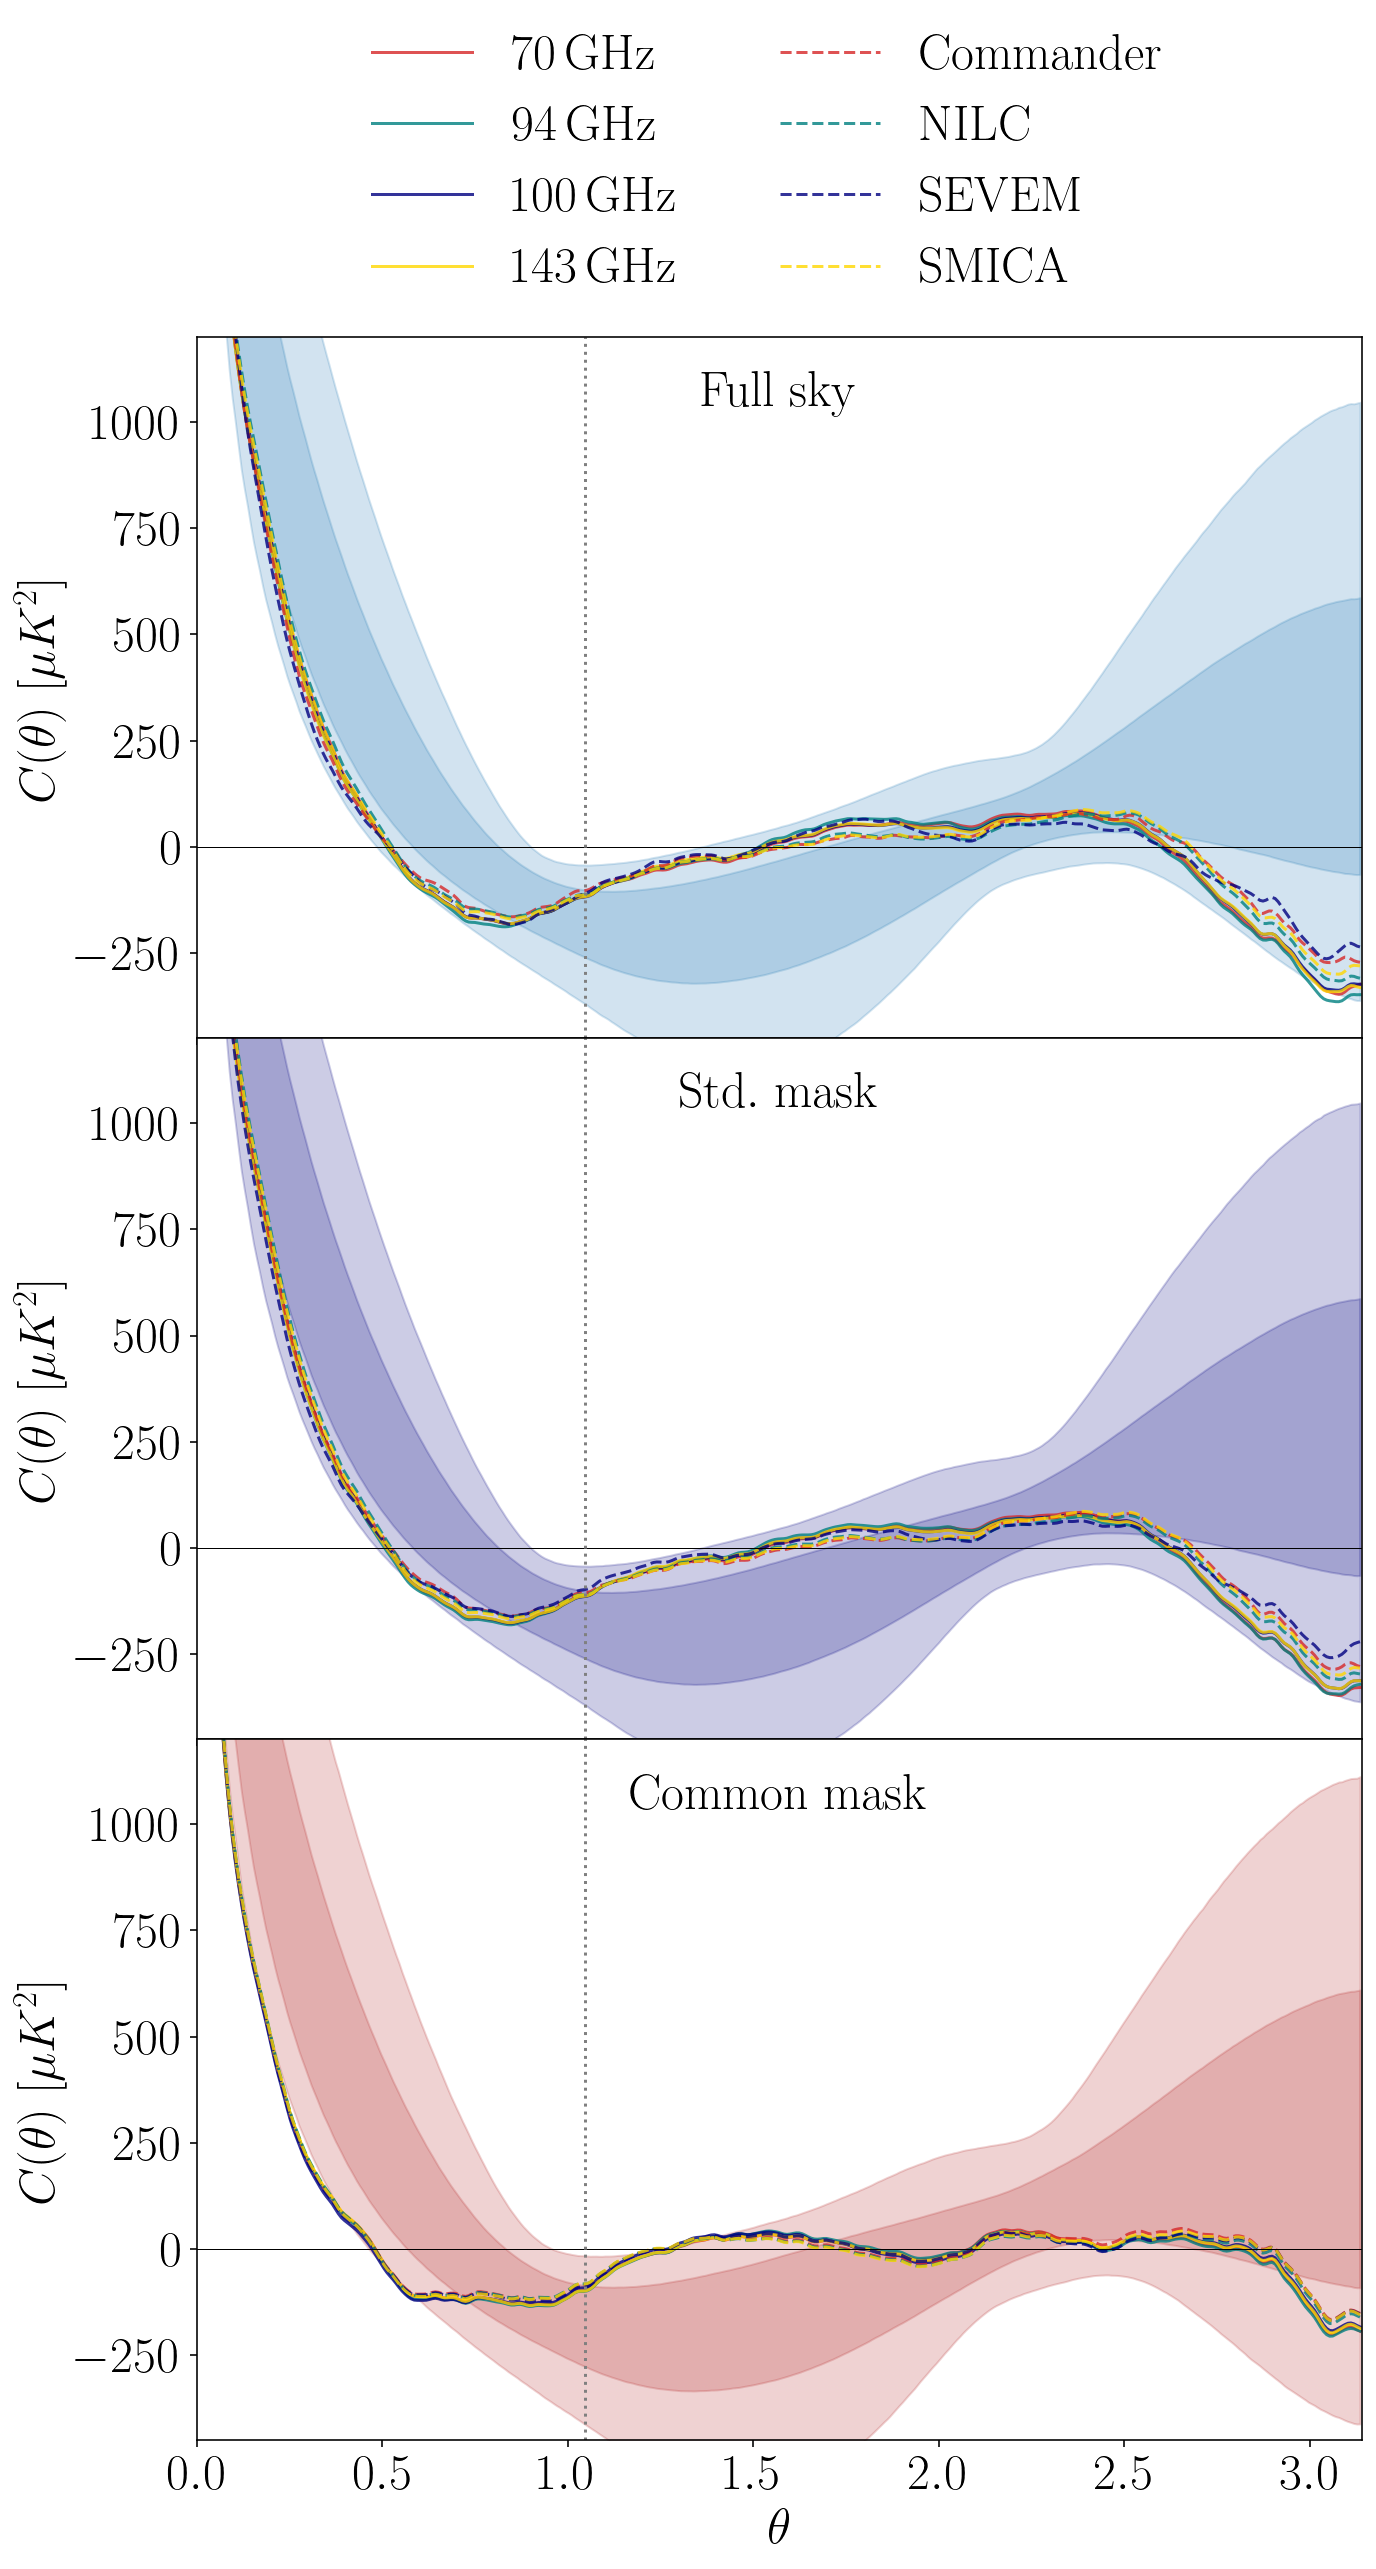

In [11]:
plt.rc('font',**{'family':'Helvetica','size':25})
fig, axs = plt.subplots(Nmasks, 1, figsize=(10, 17), sharex=True, gridspec_kw={'hspace': 0})

for m in range(Nmasks):
    for n in range(Nmaps): 
        axs[m].plot(theta, corr_Planck[m][n], label=labels_Planck[n], ls=lss_Planck[n], color=colors_Planck[n], alpha=0.8)
    axs[m].fill_between(theta, perc_68_lower[m], perc_68_upper[m], alpha=0.2, color=colors_mask[m])
    axs[m].fill_between(theta, perc_95_lower[m], perc_95_upper[m], alpha=0.2, color=colors_mask[m])
    axs[m].set_ylim(-450, 1200)
    axs[m].set_xlim(0, np.pi)
    axs[m].set_ylabel(r"$C(\theta)\ [\mu K^2]$")
    axs[m].axhline(0, color="black", lw=0.5)
    axs[m].axvline(60/180*np.pi, color="grey", ls=":")
    axs[m].text(0.5, 0.9, labels_mask[m], horizontalalignment='center', transform=axs[m].transAxes)

axs[-1].set_xlabel(r"$\theta$")
fig.legend(labels_Planck, loc='upper center', ncol=2, bbox_to_anchor=(0.55, 1.1), frameon=False)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.savefig("corr_fct_all.pdf", format="PDF", bbox_inches='tight')
plt.show()

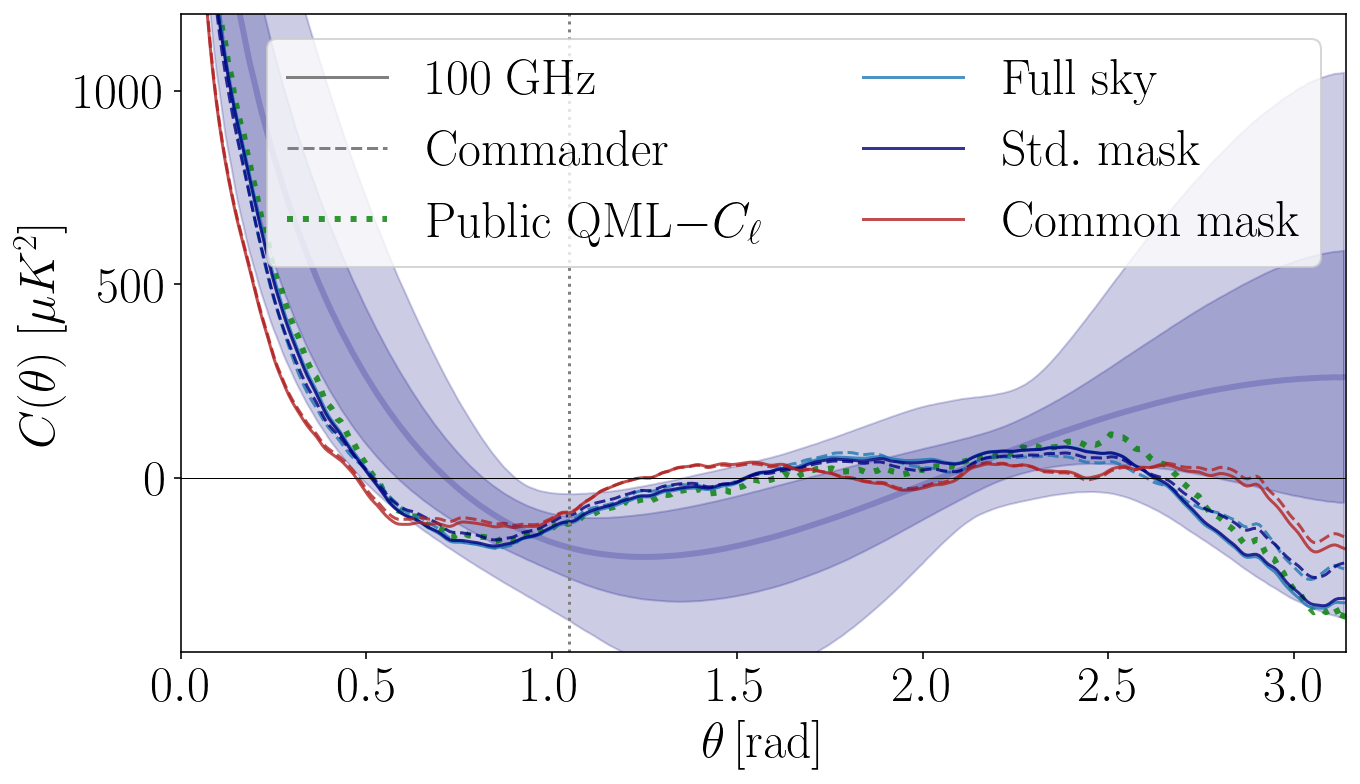

In [12]:
fig = plt.figure(figsize=(10, 6))
plt.plot([0], [0], color='grey', ls="-", label=r'$100\ \mathrm{GHz}$')
plt.plot([0], [0], color='grey', ls="--", label=r'$\mathrm{Commander}$')
plt.plot(theta, corr_qml, color=color_qml, alpha=0.8, ls=":", lw=3, label=label_qml)

for m in range(Nmasks):
    plt.plot(theta, corr_Planck[m][index_Hayley], color=colors_mask[m], alpha=0.8, ls="-", label=labels_mask[m])
    plt.plot(theta, corr_Planck[m][index_Planck], color=colors_mask[m], alpha=0.8, ls="--")
m = 1
plt.fill_between(theta, perc_68_lower[m], perc_68_upper[m], alpha= 0.2, color=colors_mask[m])
plt.fill_between(theta, perc_95_lower[m], perc_95_upper[m], alpha= 0.2, color=colors_mask[m])
#plt.plot(theta, corr_theory, color=colors_mask[m], ls="-", alpha=0.2, lw=3)
plt.plot(theta, mean_corrs[m], color=colors_mask[m], ls="-", alpha=0.2, lw=3)
plt.ylim(-450, 1200)
plt.xlim(0, np.pi)
plt.xlabel(r"$\theta\,\mathrm{[rad]}$")
plt.ylabel(r"$C(\theta)\ [\mu K^2]$")
plt.axhline(0, color="black", lw=0.5)
plt.axvline(60/180*np.pi, color="grey", ls=":")
plt.legend(loc="upper right", ncol=2)
plt.tight_layout()
#plt.savefig("Corr_fct.pdf", format="PDF")
plt.show()

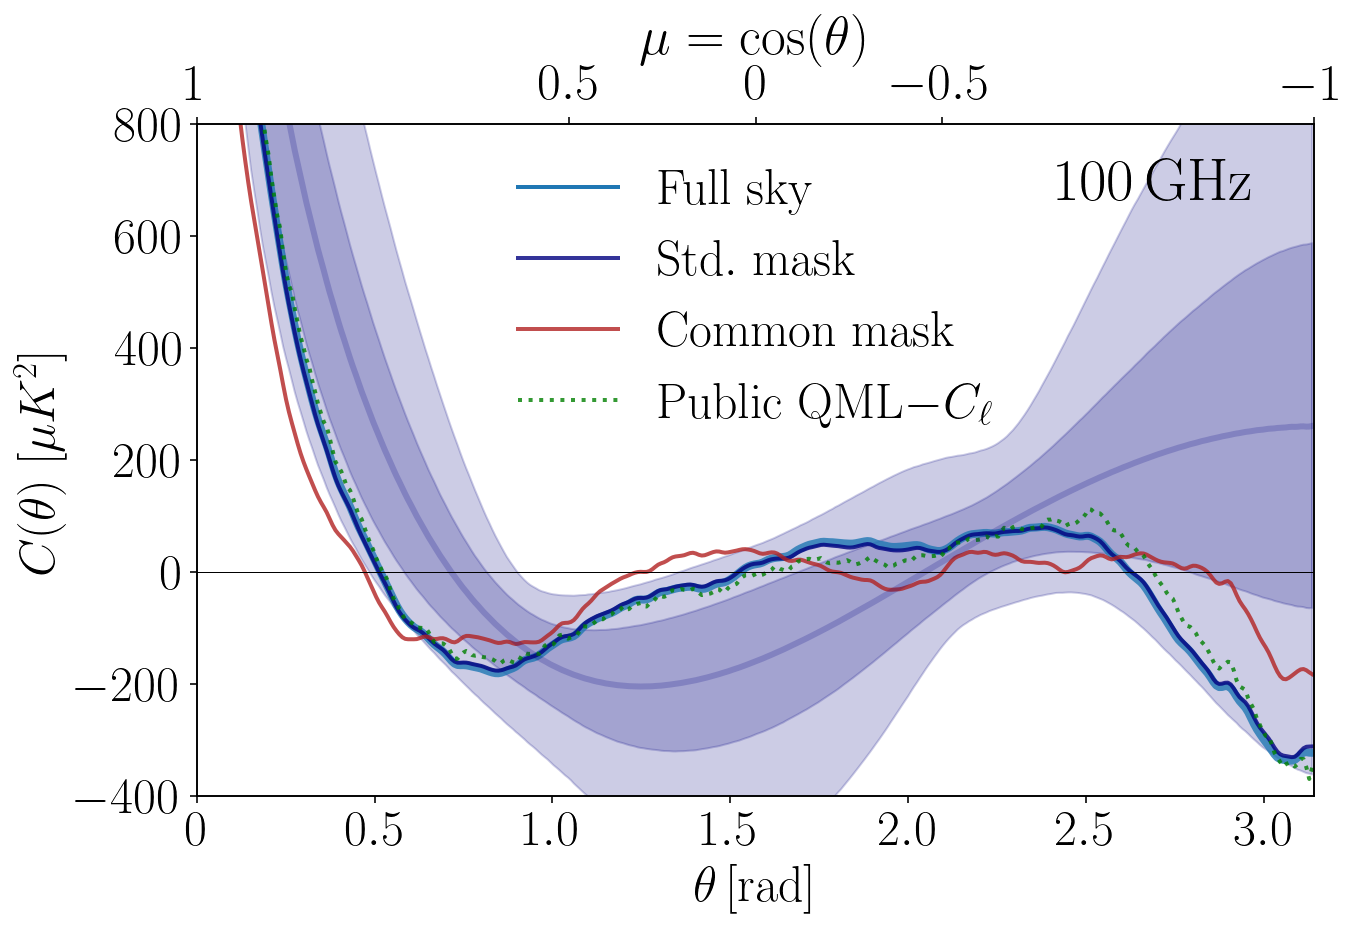

In [13]:
fig = plt.figure(figsize=(10, 7))
mu_values = np.cos(theta)

m = 0
plt.plot([0], [0], color=colors_mask[m], ls="-", label=labels_mask[m], lw=2)
plt.plot(theta, corr_Planck[m][index_Hayley], color=colors_mask[m], alpha=0.8, ls="-", lw=4)
m = 1
plt.plot(theta, corr_Planck[m][index_Hayley], color=colors_mask[m], alpha=0.8, ls="-", label=labels_mask[m], lw=2)
m = 2
plt.plot(theta, corr_Planck[m][index_Hayley], color=colors_mask[m], alpha=0.8, ls="-", label=labels_mask[m], lw=2)
m = 1
plt.fill_between(theta, perc_68_lower[m], perc_68_upper[m], alpha=0.2, color=colors_mask[m])
plt.fill_between(theta, perc_95_lower[m], perc_95_upper[m], alpha=0.2, color=colors_mask[m])
plt.plot(theta, corr_qml, color=color_qml, alpha=0.8, ls=":", lw=2, label=label_qml)
plt.plot(theta, mean_corrs[m], color=colors_mask[m], ls="-", alpha=0.2, lw=3)

plt.ylim(-400, 800)
plt.xlim(0, np.pi)
plt.xticks([0, 0.5, 1, 1.5, 2, 2.5, 3], labels=[r"$0$", r"$0.5$", r"$1.0$", r"$1.5$", r"$2.0$", r"$2.5$", r"$3.0$"])
plt.xlabel(r"$\theta\,\mathrm{[rad]}$")
plt.ylabel(r"$C(\theta)\ [\mu K^2]$")
plt.axhline(0, color="black", lw=0.5)
plt.legend(loc="upper center", frameon=False)


# Add x-labels at the top for mu = cos(theta)
ax = plt.gca()
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())

mu_ticks = [-1, -0.5, 0, 0.5, 1]
theta_ticks = np.arccos(mu_ticks)  # Convert mu values to theta
ax_top.set_xticks(theta_ticks, labels=[r"$-1$", r"$-0.5$", r"$0$", r"$0.5$", r"$1$"], fontsize=26)
ax_top.set_xlabel(r"$\mu = \cos(\theta)$", fontsize=27)

plt.text(0.95, 0.95, labels_Planck[index_Hayley], horizontalalignment='right', verticalalignment='top', transform=ax.transAxes, fontsize=30)

plt.tight_layout()
plt.show()

## Compute $S_{1/2}$

In [14]:
if load_stats_from_cluster: 
    Smu_sims = np.array([np.loadtxt(stats_dir+f"Smu_sims_{names_mask[m]}_Nsims_{Nsims}.npy") for m in range(Nmasks)])
else:                       
    Smu_sims = np.array([[CMBanom.S_mu_many(corrs[m], cos_theta, mu, method) for mu in mus] for m in range(Nmasks)])

mean_Smu_sims = np.mean(Smu_sims, axis=2)
perc_68_lower_Smu = np.percentile(Smu_sims, (100-68.27)/2, axis=2)
perc_68_upper_Smu = np.percentile(Smu_sims, 68.27+(100-68.27)/2, axis=2)
perc_95_lower_Smu = np.percentile(Smu_sims, (100-95.45)/2, axis=2)
perc_95_upper_Smu = np.percentile(Smu_sims, 95.45+(100-95.45)/2, axis=2)

In [15]:
Smu_Planck = np.array([[[CMBanom.S_mu(corr_Planck[m][n], cos_theta, mu, method) for mu in mus] for n in range(Nmaps)] for m in range(Nmasks)])
Smu_Planck_QML = np.array([CMBanom.S_mu_many([corr_qml], cos_theta, mu) for mu in mus])

## Plot $S_{1/2}$

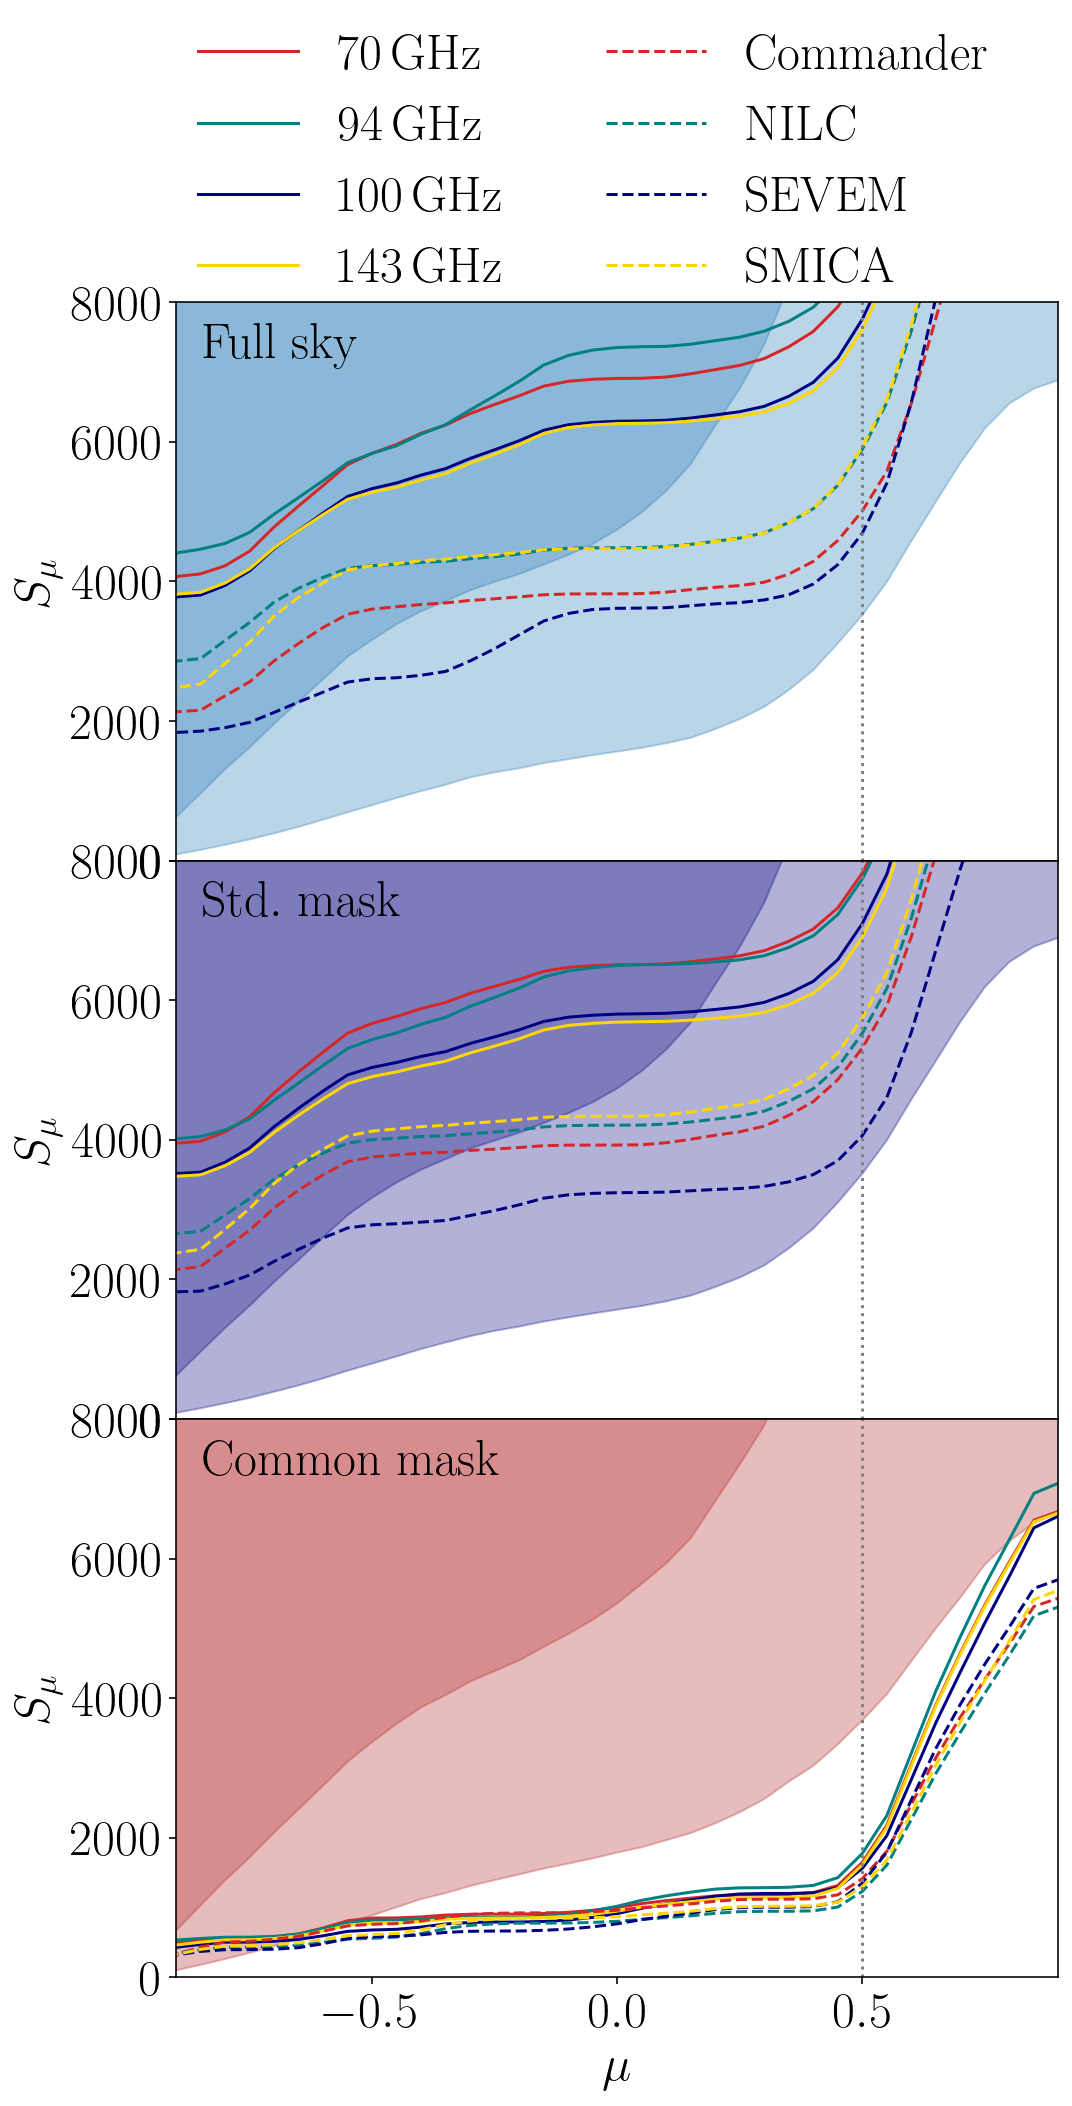

In [16]:
plt.rc('font',**{'family':'Helvetica','size':25})
fig, axs = plt.subplots(Nmasks, 1, figsize=(8, 14), sharex=True, gridspec_kw={'hspace': 0})

for m in range(Nmasks):
    for n in range(Nmaps): 
        axs[m].plot(mus, Smu_Planck[m][n], label=labels_Planck[n], color=colors_Planck[n], ls=lss_Planck[n])
    axs[m].fill_between(mus, perc_68_lower_Smu[m], perc_68_upper_Smu[m], color=colors_mask[m], alpha=0.3)
    axs[m].fill_between(mus, perc_95_lower_Smu[m], perc_95_upper_Smu[m], color=colors_mask[m], alpha=0.3)
    axs[m].axvline(0.5, color="grey", ls=":")
    
    axs[m].set_ylim(0,8000)
    axs[m].set_xlim(-0.9,0.9)
    axs[m].set_ylabel(r"$S_\mu$")
    axs[m].text(0.03, 0.9, labels_mask[m], horizontalalignment='left', transform=axs[m].transAxes)

axs[-1].set_xlabel(r"$\mu$")
fig.legend(labels_Planck, loc='upper center', ncol=2, bbox_to_anchor=(0.55, 1.1), frameon=False)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

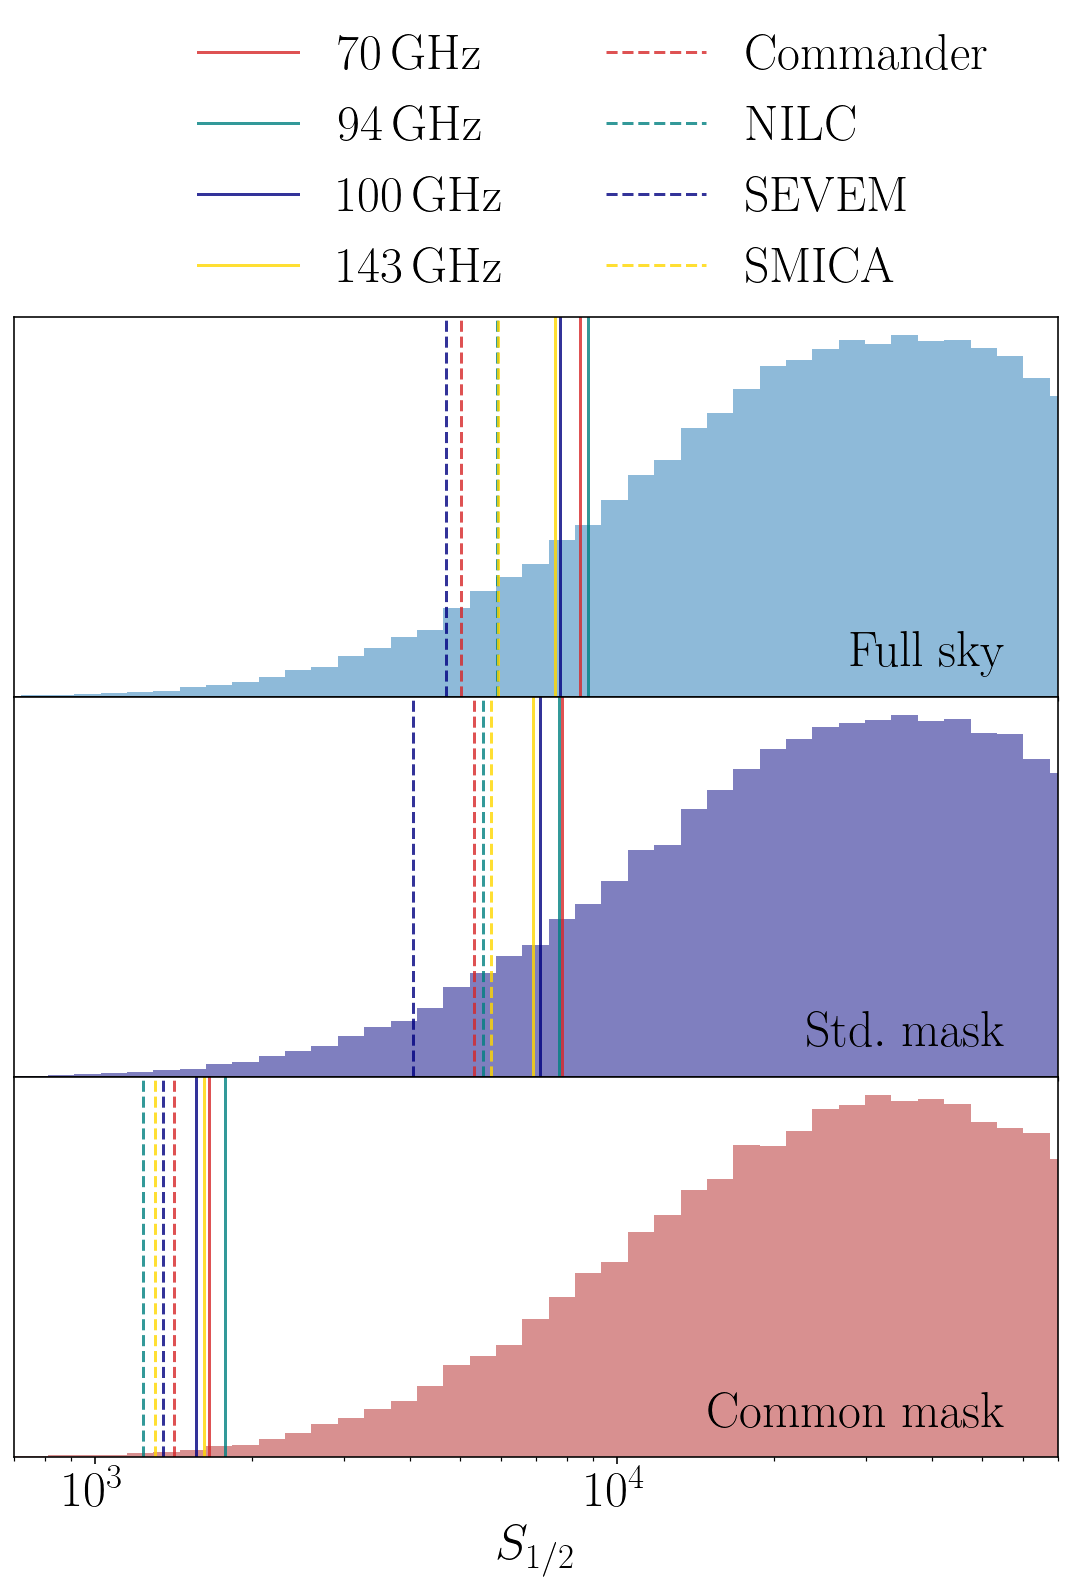

In [17]:
plt.rc('font',**{'family':'Helvetica','size':25})
fig, axs = plt.subplots(Nmasks, 1, figsize=(8, 10), sharex=True, gridspec_kw={'hspace': 0})
bins = 10**np.linspace(2, 7, 100)

for m in range(Nmasks):
    for n in range(Nmaps): 
        axs[m].axvline(Smu_Planck[m][n][mu_index], color=colors_Planck[n], ls=lss_Planck[n], label=labels_Planck[n], alpha=0.8)
    axs[m].hist(Smu_sims[m][mu_index], bins=bins, color=colors_mask[m], alpha=0.5)
    
    axs[m].set_xscale("log")
    axs[m].set_xlim(7e2, 7e4)
    axs[m].tick_params(axis='y', which='both', left=False, labelleft=False) 
    axs[m].text(0.95, 0.05, labels_mask[m], horizontalalignment='right', verticalalignment='bottom', transform=axs[m].transAxes)

axs[-1].set_xlabel(r"$S_{1/2}$")
fig.legend(labels_Planck, loc='upper center', ncol=2, bbox_to_anchor=(0.55, 1.17), frameon=False)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

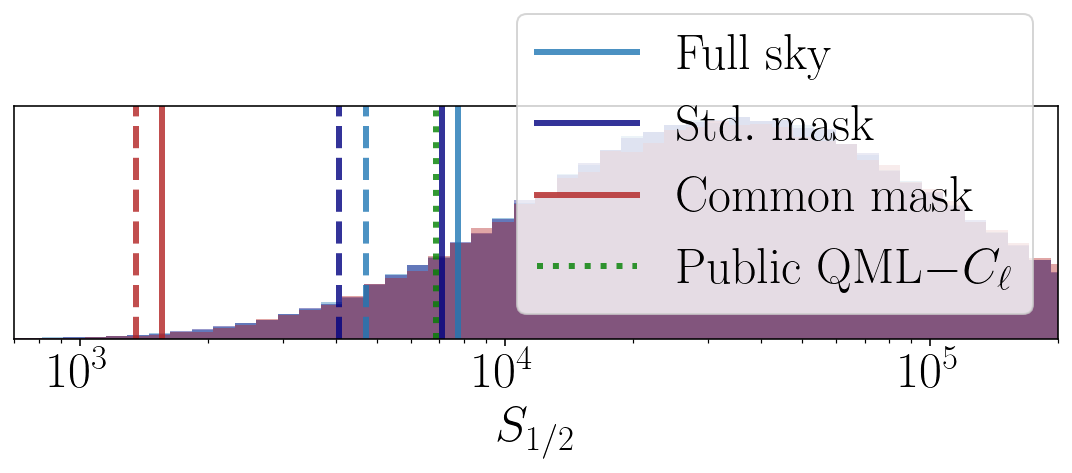

In [18]:
fig = plt.figure(figsize=(8, 3.2))
bins = 10**np.linspace(2, 7, 100)
#plt.plot([0], [0], color='grey', ls="-", lw=3, label=labels_Planck[index_Hayley])
#plt.plot([0], [0], color='grey', ls="--", lw=3, label=labels_Planck[index_Planck])
for m in range(Nmasks):
    h=plt.hist(Smu_sims[m][mu_index], bins=bins, color=colors_mask[m], alpha=0.4)
    plt.axvline(Smu_Planck[m][index_Hayley][mu_index], color=colors_mask[m], lw=3, alpha=0.8, ls="-", label=labels_mask[m])
    plt.axvline(Smu_Planck[m][index_Planck][mu_index], color=colors_mask[m], lw=3, alpha=0.8, ls="--")
plt.axvline(Smu_Planck_QML[mu_index], color=color_qml, lw=3, alpha=0.8, ls=":", label=label_qml)
plt.xlim(7e2, 2e5)
plt.xscale("log")
plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
plt.xlabel(r"$S_{1/2}$")
#plt.legend(loc='center right', bbox_to_anchor=(2.8, 0.5), ncol=1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("hist_S_12.pdf", format="PDF")
plt.show()

# Save stats to file

In [19]:
if save_stats: 
    np.save(stats_dir+"Smu_real", Smu_Planck)
    np.save(stats_dir+"Smu_real_QML", Smu_Planck_QML)

# Compute p-values (in %)

In [20]:
p_Planck     = np.array([[[CMBanom.pval_lower(Smu_Planck[m][n][mu], Smu_sims[m][mu])  for mu in range(Nmus)] for n in range(Nmaps)] for m in range(Nmasks)])
p_Planck_QML = np.array([[CMBanom.pval_lower(Smu_Planck_QML[mu], Smu_sims[m][mu]) for mu in range(Nmus)] for m in range(Nmasks)])

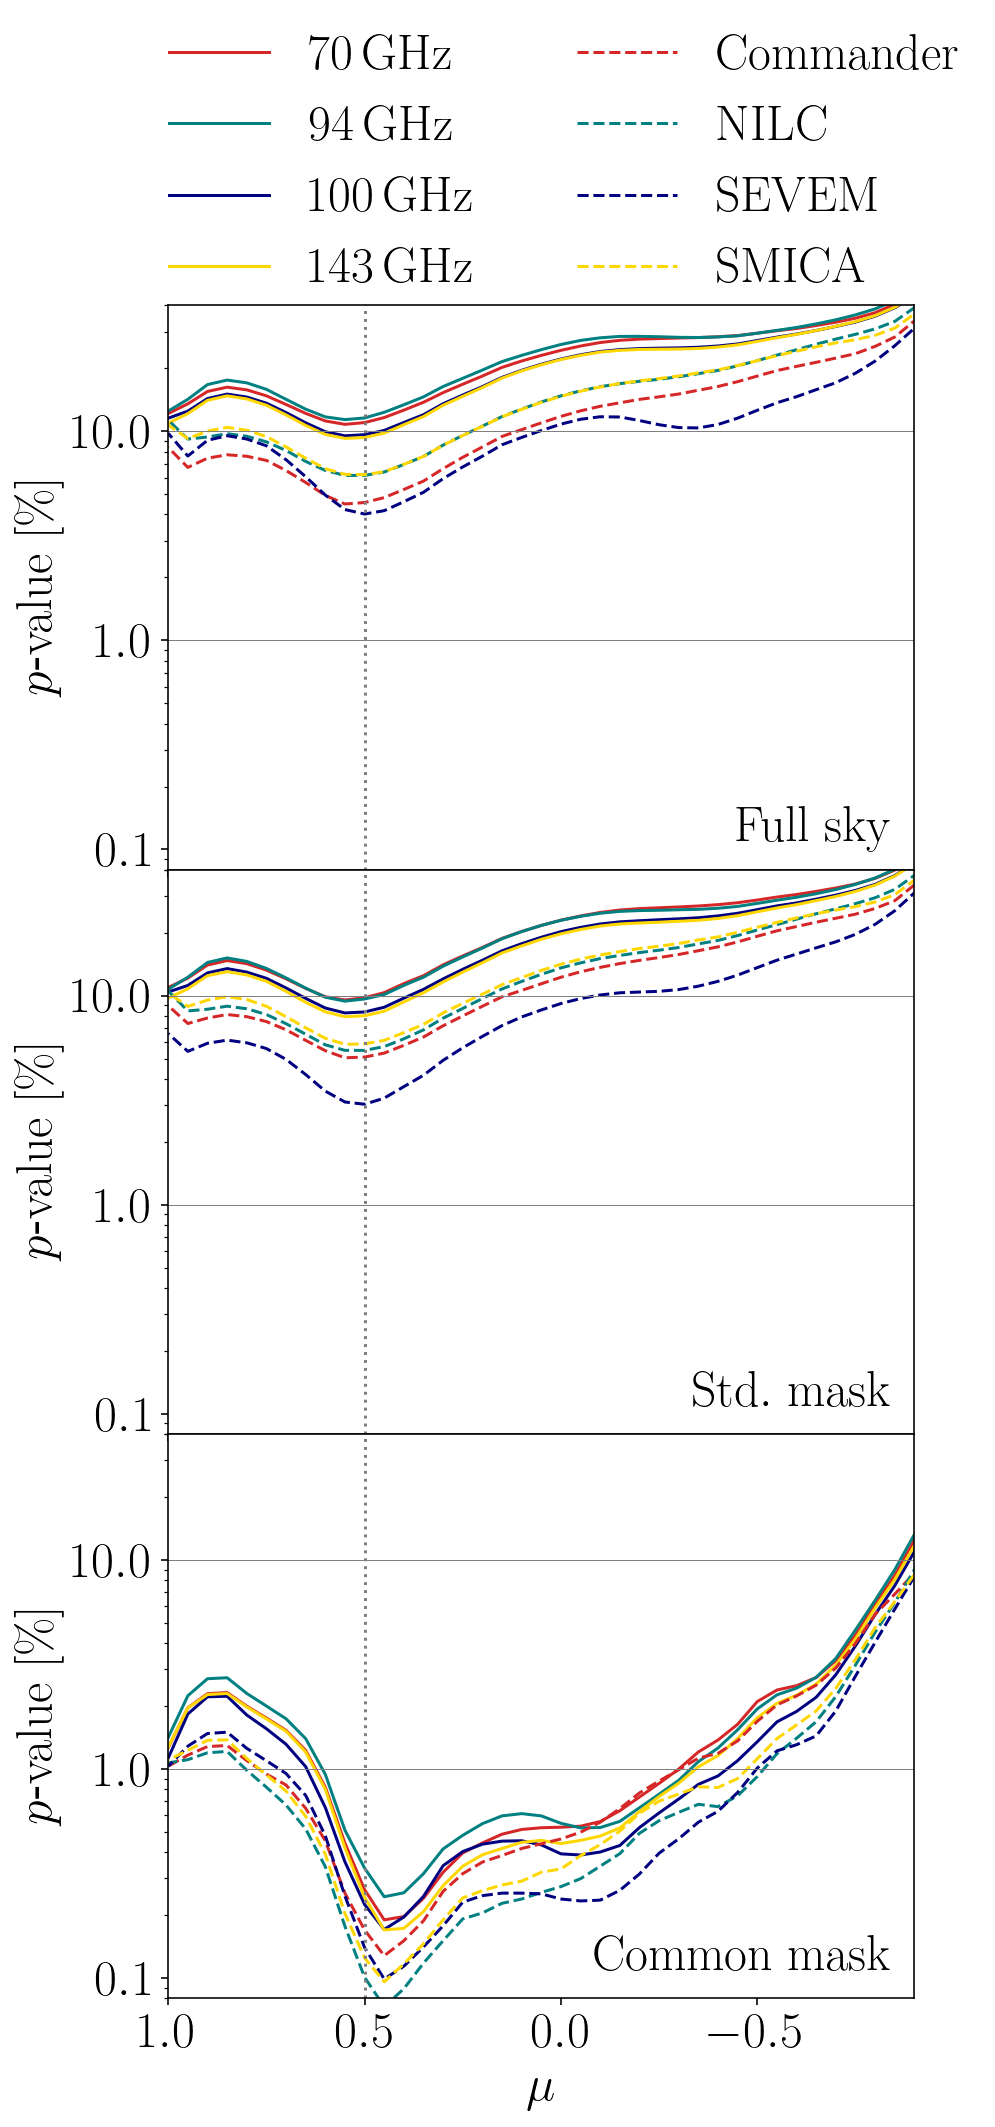

In [21]:
plt.rc('font',**{'family':'Helvetica','size':25})
fig, axs = plt.subplots(Nmasks, 1, figsize=(7, 14), sharex=True, gridspec_kw={'hspace': 0})

for m in range(Nmasks):
    for n in range(Nmaps): 
        axs[m].semilogy(mus, 100*p_Planck[m][n], label=labels_Planck[n], color=colors_Planck[n], ls=lss_Planck[n])
    axs[m].axvline(0.5, color="grey", ls=":")
    axs[m].axhline(1, color="grey", ls="-", lw=.5)
    axs[m].axhline(10, color="grey", ls="-", lw=.5)
    
    axs[m].set_ylim(8e-2,40)
    axs[m].set_xlim(1, -0.9)
    axs[m].set_ylabel(r"$p$-$\mathrm{value}\ [\%]$")
    axs[m].set_yticks([0.1, 1.0, 10.0], labels=["$0.1$", "$1.0$", "$10.0$"])
    #axs[m].text(0.5, 0.9, labels_mask[m], horizontalalignment='center', transform=axs[m].transAxes)
    axs[m].text(0.97, 0.03, labels_mask[m], horizontalalignment='right', verticalalignment='bottom', transform=axs[m].transAxes)

axs[-1].set_xlabel(r"$\mu$")
fig.legend(labels_Planck, loc='upper center', ncol=2, bbox_to_anchor=(0.6, 1.11), frameon=False)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.savefig("Smu_p-values_all.pdf", format="PDF", bbox_inches="tight")
plt.show()

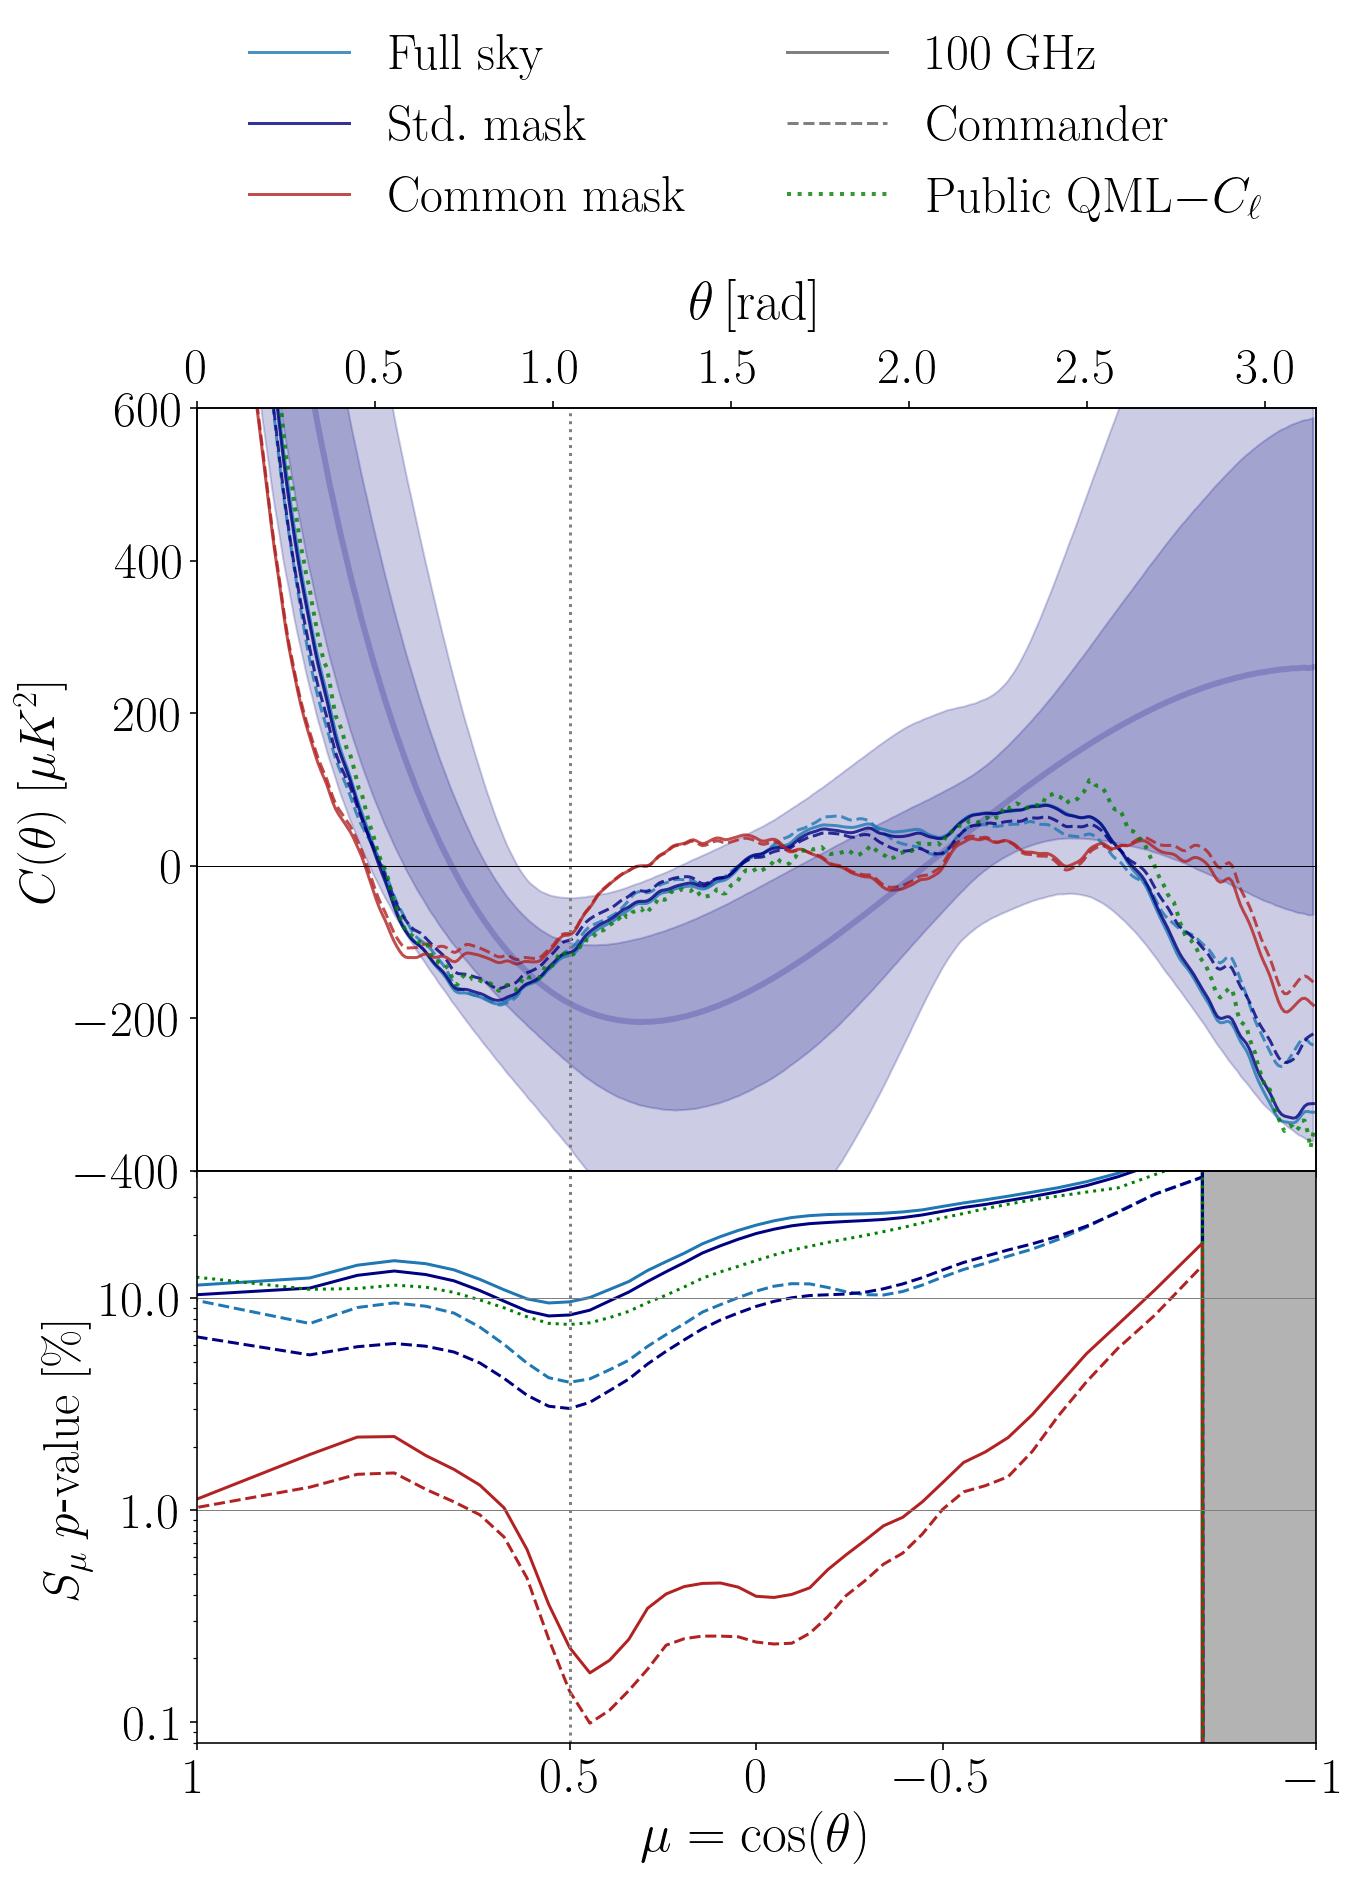

In [24]:
fig, axs = plt.subplots(2, 1, figsize=(10, 15), sharex=True, gridspec_kw={'height_ratios': [4, 3], 'hspace': 0})

# Top subplot
ax = axs[0]
mu_values = np.cos(theta)
theta_mus = np.arccos(mus)

for m in range(Nmasks):
    ax.plot(theta, corr_Planck[m][index_Hayley], color=colors_mask[m], alpha=0.8, ls="-", label=labels_mask[m])
    ax.plot(theta, corr_Planck[m][index_Planck], color=colors_mask[m], alpha=0.8, ls="--")
    
ax.plot([0], [0], color='grey', ls="-", label=r'$100\ \mathrm{GHz}$')
ax.plot([0], [0], color='grey', ls="--", label=r'$\mathrm{Commander}$')
ax.plot(theta, corr_qml, color=color_qml, alpha=0.8, ls=":", lw=2, label=label_qml)


m = 1
ax.fill_between(theta, perc_68_lower[m], perc_68_upper[m], alpha=0.2, color=colors_mask[m])
ax.fill_between(theta, perc_95_lower[m], perc_95_upper[m], alpha=0.2, color=colors_mask[m])
ax.plot(theta, mean_corrs[m], color=colors_mask[m], ls="-", alpha=0.2, lw=3)
ax.axvline(theta_mus[mu_index], color="grey", ls=":")

ax.set_ylim(-400, 600)
ax.set_xlim(0, np.pi)
ax.set_ylabel(r"$C(\theta)\ [\mu K^2]$")
ax.axhline(0, color="black", lw=0.5)
ax.legend(loc="upper center", frameon=False, ncol=2, bbox_to_anchor=(0.5, 1.55))

# Add x-labels at the top for theta
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks([0, 0.5, 1, 1.5, 2, 2.5, 3])
ax_top.set_xticklabels([r"$0$", r"$0.5$", r"$1.0$", r"$1.5$", r"$2.0$", r"$2.5$", r"$3.0$"])
ax_top.set_xlabel(r"$\theta\,\mathrm{[rad]}$", fontsize=27, labelpad=15)  # Increase labelpad to move it further up

# Bottom subplot
ax = axs[1]

for m in range(Nmasks): 
    ax.semilogy(theta_mus, 100*p_Planck[m][index_Hayley], label=labels_mask[m], color=colors_mask[m], ls=lss_Planck[index_Hayley])
    ax.semilogy(theta_mus, 100*p_Planck[m][index_Planck], color=colors_mask[m], ls=lss_Planck[index_Planck])
ax.semilogy(theta_mus, 100*p_Planck_QML[2], label=label_qml, color=color_qml, ls=":")
ax.axvline(theta_mus[mu_index], color="grey", ls=":")
ax.axhline(1, color="grey", ls="-", lw=.5)
ax.axhline(10, color="grey", ls="-", lw=.5)
ax.axvspan(2.82, np.pi, alpha=0.5, color='dimgrey')

ax.set_ylim(8e-2, 40)
ax.set_xlim(0, np.pi)
ax.set_ylabel(r"$S_\mu\ p$-$\mathrm{value}\ [\%]$")
ax.set_yticks([0.1, 1.0, 10.0])
ax.set_yticklabels(["$0.1$", "$1.0$", "$10.0$"])

# Add x-labels at the bottom for mu
ax.set_xticks(theta_ticks)
ax.set_xticklabels([r"$-1$", r"$-0.5$", r"$0$", r"$0.5$", r"$1$"])
ax.set_xlabel(r"$\mu = \cos(\theta)$", fontsize=27)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.savefig("corr_100GHz_commander.pdf", format="PDF", bbox_inches="tight")
plt.show()

In [23]:
print("-----------")
for m in range(Nmasks):
    print(names_mask[m])
    print("-----------")
    for n in range(Nmaps): print(f"S_1/2 = {Smu_Planck[m][n][mu_index]:.0f}, p = {100*p_Planck[m][n][mu_index]:.2f}% ({names_Planck[n]})")
    print("-----------")

-----------
fullsky
-----------
S_1/2 = 8479, p = 11.01% (v9_70GHz_POBSdebias)
S_1/2 = 8791, p = 11.58% (v9_94GHz_POBSdebias)
S_1/2 = 7756, p = 9.63% (v9_100GHz_POBSdebias)
S_1/2 = 7609, p = 9.34% (v9_143GHz_POBSdebias)
S_1/2 = 5009, p = 4.56% (commander_nside_128)
S_1/2 = 5892, p = 6.15% (nilc_nside_128)
S_1/2 = 4690, p = 4.02% (sevem_nside_128)
S_1/2 = 5922, p = 6.20% (smica_nside_128)
-----------
stdmask
-----------
S_1/2 = 7822, p = 9.77% (v9_70GHz_POBSdebias)
S_1/2 = 7738, p = 9.63% (v9_94GHz_POBSdebias)
S_1/2 = 7097, p = 8.35% (v9_100GHz_POBSdebias)
S_1/2 = 6902, p = 8.01% (v9_143GHz_POBSdebias)
S_1/2 = 5315, p = 5.08% (commander_nside_128)
S_1/2 = 5526, p = 5.47% (nilc_nside_128)
S_1/2 = 4060, p = 3.02% (sevem_nside_128)
S_1/2 = 5742, p = 5.88% (smica_nside_128)
-----------
commask
-----------
S_1/2 = 1648, p = 0.27% (v9_70GHz_POBSdebias)
S_1/2 = 1776, p = 0.34% (v9_94GHz_POBSdebias)
S_1/2 = 1561, p = 0.22% (v9_100GHz_POBSdebias)
S_1/2 = 1613, p = 0.24% (v9_143GHz_POBSdebias)
S_

In [ ]:
Smu_sims[0].T[0]

In [ ]:
p_Planck[0][0]

In [ ]:
mus